In [2]:
%load_ext autoreload
%autoreload 2

import sys
from pathlib import Path

# Find the project root that contains the src folder
current = Path.cwd().resolve()

for p in [current] + list(current.parents):
    if (p / "src").exists():
        repo_root = p
        break
else:
    raise FileNotFoundError("Could not find a folder containing 'src'.")

if str(repo_root) not in sys.path:
    sys.path.insert(0, str(repo_root))

print("Current working directory:", current)
print("Added repo root:", repo_root)
print("src exists:", (repo_root / "src").exists())

from pathlib import Path
import numpy as np
import pandas as pd

import src.utils.pdata_io as pdio
from src.proc.extract_epoch_windows import load_epoch_windows

data_root, pdata_root, cc_data = pdio.load_project_context()

windows_df = load_epoch_windows(
    pdata_root=pdata_root,
    filename="behavior_epoch_windows.h5",
    key="windows/prepost_1s"
)

valid_windows = windows_df[windows_df["valid_window"]].copy()

print("All windows:", windows_df.shape)
print("Valid windows:", valid_windows.shape)

valid_windows.groupby(["phase", "epoch_name"]).size().reset_index(name="n_windows")

encoder_epoch_df = pd.read_hdf(
    Path(pdata_root) / "_cache" / "behavior_epoch_metrics.h5",
    key="encoder/prepost_1s_speedThresh_1cms"
)

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload
Current working directory: /home/nmldata2/ccaw/Python/notebooks
Added repo root: /home/nmldata2/ccaw/Python
src exists: True
/home/nmldata2/ccaw/Python
[LOADED] Project context: /mnt/pdata/Classical_Conditioning/_cache/project_context.pkl
[LOADED] Epoch windows: /mnt/pdata/Classical_Conditioning/_cache/behavior_epoch_windows.h5
[KEY] windows/prepost_1s
All windows: (42388, 16)
Valid windows: (38660, 16)


In [3]:
from src.proc.behavior_metrics import add_normalized_phase_day

encoder_epoch_df = add_normalized_phase_day(encoder_epoch_df)
encoder_epoch_df.head()

,animal,date,phase,event_number,anchor_name,anchor_time_s,window_position,window_s,epoch_name,window_start_s,...,net_direction_bias,frac_stationary,frac_moving,frac_forward,frac_backward,frac_low_net_movement,dominant_locomotor_state,phase_session_number,n_sessions_in_phase,normalized_phase_day
0,NML_04,2026_01_12,air_training,1,air_off,23.979000,post,1.0,air_off_post_1s,23.979000,...,1.000000,0.0000,1.0000,1.0000,0.0000,0.0,forward,1.0,15.0,0.0
1,NML_04,2026_01_12,air_training,1,air_off,23.979000,pre,1.0,air_off_pre_1s,22.979000,...,0.951624,0.0340,0.9660,0.8530,0.1130,0.0,forward,1.0,15.0,0.0
2,NML_04,2026_01_12,air_training,1,air_on,19.956400,post,1.0,air_on_post_1s,19.956400,...,-0.487133,0.5560,0.4440,0.0924,0.3516,0.0,stationary,1.0,15.0,0.0
3,NML_04,2026_01_12,air_training,1,air_on,19.956400,pre,1.0,air_on_pre_1s,18.956400,...,0.799008,0.3630,0.6370,0.5644,0.0726,0.0,forward,1.0,15.0,0.0
4,NML_04,2026_01_12,air_training,2,air_off,41.279202,post,1.0,air_off_post_1s,41.279202,...,0.982488,0.1328,0.8672,0.8480,0.0192,0.0,forward,1.0,15.0,0.0


In [5]:

from src.proc.behavior_metrics import make_session_epoch_summary

session_epoch_df = make_session_epoch_summary(encoder_epoch_df)
session_epoch_df.head()

,animal,date,phase,phase_session_number,normalized_phase_day,epoch_name,anchor_name,window_position,mean_speed_path_cms,median_speed_path_cms,...,median_speed_net_cms,distance_path_cm,distance_net_cm,frac_stationary,frac_moving,frac_forward,frac_backward,frac_low_net_movement,net_direction_bias,n_windows
0,NML_04,2025_12_27,habituation,1.0,0.000000,LED_off_post_1s,LED_off,post,0.861822,0.691150,...,0.229336,0.886557,0.243159,0.648290,0.351710,0.210370,0.141340,0.0,0.306804,40
1,NML_04,2025_12_27,habituation,1.0,0.000000,LED_off_pre_1s,LED_off,pre,0.905962,0.747699,...,0.037699,0.930540,0.093619,0.637780,0.362220,0.190975,0.171245,0.0,0.271213,40
2,NML_04,2025_12_27,habituation,1.0,0.000000,LED_on_post_1s,LED_on,post,1.030293,0.794823,...,-0.072257,1.058088,0.232478,0.580695,0.419305,0.263135,0.156170,0.0,0.394710,40
3,NML_04,2025_12_27,habituation,1.0,0.000000,LED_on_pre_1s,LED_on,pre,0.604111,0.439823,...,0.037699,0.620150,0.059690,0.681305,0.318695,0.166150,0.152545,0.0,0.250335,40
4,NML_04,2025_12_28,habituation,2.0,0.066667,LED_off_post_1s,LED_off,post,0.410003,0.269717,...,0.049039,0.419288,0.085819,0.730410,0.269590,0.149415,0.120176,0.0,0.232713,41


In [6]:
import statsmodels.formula.api as smf


air_df = session_epoch_df[
    session_epoch_df["phase"] == "air_training"
].copy()

model = smf.mixedlm(
    "mean_speed_path_cms ~ C(anchor_name) * C(window_position) + normalized_phase_day",
    data=air_df,
    groups=air_df["animal"]
)

result = model.fit(method="lbfgs")
print(result.summary())

                            Mixed Linear Model Regression Results
Model:                      MixedLM          Dependent Variable:          mean_speed_path_cms
No. Observations:           312              Method:                      REML               
No. Groups:                 5                Scale:                       3.2124             
Min. group size:            60               Log-Likelihood:              inf                
Max. group size:            68               Converged:                   Yes                
Mean group size:            62.4                                                             
---------------------------------------------------------------------------------------------
                                                   Coef.  Std.Err.   z    P>|z| [0.025 0.975]
---------------------------------------------------------------------------------------------
Intercept                                          -0.000                               

/home/nmldata2/miniconda3/envs/air_wheel/lib/python3.8/site-packages/statsmodels/regression/mixed_linear_model.py:1635: UserWarning: Random effects covariance is singular
  warnings.warn(msg)
/home/nmldata2/miniconda3/envs/air_wheel/lib/python3.8/site-packages/statsmodels/regression/mixed_linear_model.py:2055: UserWarning: The random effects covariance matrix is singular.
  warnings.warn(_warn_cov_sing)
/home/nmldata2/miniconda3/envs/air_wheel/lib/python3.8/site-packages/statsmodels/regression/mixed_linear_model.py:2238: ConvergenceWarning: The MLE may be on the boundary of the parameter space.
  warnings.warn(msg, ConvergenceWarning)
/home/nmldata2/miniconda3/envs/air_wheel/lib/python3.8/site-packages/statsmodels/regression/mixed_linear_model.py:2246: UserWarning: The random effects covariance matrix is singular.
  warnings.warn(_warn_cov_sing)
/home/nmldata2/miniconda3/envs/air_wheel/lib/python3.8/site-packages/statsmodels/regression/mixed_linear_model.py:2262: ConvergenceWarning: Th

In [7]:
from src.proc.behavior_metrics import make_prepost_delta_table

delta_speed_df = make_prepost_delta_table(session_epoch_df, "mean_speed_path_cms")
delta_forward_df = make_prepost_delta_table(session_epoch_df, "frac_forward")
delta_stationary_df = make_prepost_delta_table(session_epoch_df, "frac_stationary")

In [9]:
from src.proc.behavior_metrics import fit_delta_lmm
fit_delta_lmm(delta_speed_df, "air_training", "mean_speed_path_cms")
fit_delta_lmm(delta_speed_df, "tone_air_training", "mean_speed_path_cms")
fit_delta_lmm(delta_forward_df, "tone_air_training", "frac_forward")

/home/nmldata2/miniconda3/envs/air_wheel/lib/python3.8/site-packages/statsmodels/regression/mixed_linear_model.py:1635: UserWarning: Random effects covariance is singular
  warnings.warn(msg)
/home/nmldata2/miniconda3/envs/air_wheel/lib/python3.8/site-packages/statsmodels/regression/mixed_linear_model.py:2055: UserWarning: The random effects covariance matrix is singular.
  warnings.warn(_warn_cov_sing)
/home/nmldata2/miniconda3/envs/air_wheel/lib/python3.8/site-packages/statsmodels/regression/mixed_linear_model.py:2238: ConvergenceWarning: The MLE may be on the boundary of the parameter space.
  warnings.warn(msg, ConvergenceWarning)
/home/nmldata2/miniconda3/envs/air_wheel/lib/python3.8/site-packages/statsmodels/regression/mixed_linear_model.py:2246: UserWarning: The random effects covariance matrix is singular.
  warnings.warn(_warn_cov_sing)
/home/nmldata2/miniconda3/envs/air_wheel/lib/python3.8/site-packages/statsmodels/regression/mixed_linear_model.py:2262: ConvergenceWarning: Th

In [11]:
res_air_speed = fit_delta_lmm(
    delta_speed_df,
    "air_training",
    "mean_speed_path_cms"
)

print(res_air_speed.summary())

res_tone_speed = fit_delta_lmm(
    delta_speed_df,
    "tone_air_training",
    "mean_speed_path_cms"
)

print(res_tone_speed.summary())

res_tone_forward = fit_delta_lmm(
    delta_forward_df,
    "tone_air_training",
    "frac_forward"
)

print(res_tone_forward.summary())

                       Mixed Linear Model Regression Results
Model:                MixedLM     Dependent Variable:     delta_mean_speed_path_cms
No. Observations:     156         Method:                 REML                     
No. Groups:           5           Scale:                  2.8526                   
Min. group size:      30          Log-Likelihood:         inf                      
Max. group size:      34          Converged:              Yes                      
Mean group size:      31.2                                                         
-----------------------------------------------------------------------------------
                         Coef.   Std.Err.     z    P>|z|     [0.025       0.975]   
-----------------------------------------------------------------------------------
Intercept                0.000 16896407.207  0.000 1.000 -33116349.593 33116349.593
C(anchor_name)[T.air_on] 3.367        0.270 12.449 0.000         2.837        3.897
normalized_phas

/home/nmldata2/miniconda3/envs/air_wheel/lib/python3.8/site-packages/statsmodels/regression/mixed_linear_model.py:1635: UserWarning: Random effects covariance is singular
  warnings.warn(msg)
/home/nmldata2/miniconda3/envs/air_wheel/lib/python3.8/site-packages/statsmodels/regression/mixed_linear_model.py:2055: UserWarning: The random effects covariance matrix is singular.
  warnings.warn(_warn_cov_sing)
/home/nmldata2/miniconda3/envs/air_wheel/lib/python3.8/site-packages/statsmodels/regression/mixed_linear_model.py:2238: ConvergenceWarning: The MLE may be on the boundary of the parameter space.
  warnings.warn(msg, ConvergenceWarning)
/home/nmldata2/miniconda3/envs/air_wheel/lib/python3.8/site-packages/statsmodels/regression/mixed_linear_model.py:2246: UserWarning: The random effects covariance matrix is singular.
  warnings.warn(_warn_cov_sing)
/home/nmldata2/miniconda3/envs/air_wheel/lib/python3.8/site-packages/statsmodels/regression/mixed_linear_model.py:2262: ConvergenceWarning: Th

In [12]:
from src.proc.behavior_metrics import animal_level_delta_summary, test_animal_level_deltas

air_speed_animal = animal_level_delta_summary(
    delta_speed_df,
    phase="air_training",
    outcome="mean_speed_path_cms"
)

air_speed_tests = test_animal_level_deltas(air_speed_animal)

air_speed_animal, air_speed_tests

(   animal anchor_name  mean_delta  median_delta  n_sessions
 0  NML_04     air_off   -2.014635     -2.124035          15
 1  NML_04      air_on    1.332727      0.709700          15
 2  NML_05     air_off   -2.005219     -2.106604          15
 3  NML_05      air_on    1.352447      1.201702          15
 4  NML_06     air_off   -1.616017     -2.319088          15
 5  NML_06      air_on    1.684464      1.770569          15
 6  NML_07     air_off   -1.188470     -0.917164          16
 7  NML_07      air_on    0.280734      0.912496          16
 8  NML_08     air_off   -2.165299     -2.312374          17
 9  NML_08      air_on    3.071270      3.297824          17,
   anchor_name  n_animals  mean_delta  sem_delta  median_delta  t_stat_vs_0  \
 0     air_off          5   -1.797928   0.177401     -2.005219   -10.134819   
 1      air_on          5    1.544328   0.448857      1.352447     3.440578   
 
    p_ttest_vs_0  p_wilcoxon_vs_0  
 0      0.000534           0.0625  
 1      0.026280 

In [14]:
from src.proc.behavior_metrics import paired_anchor_comparison

air_on_vs_off = paired_anchor_comparison(
    air_speed_animal,
    anchor_a="air_on",
    anchor_b="air_off"
)

air_on_vs_off

{'anchor_a': 'air_on',
 'anchor_b': 'air_off',
 'n_animals': 5,
 'mean_delta_a': 1.5443281097430366,
 'mean_delta_b': -1.797927847110802,
 'mean_difference_a_minus_b': 3.342255956853839,
 'p_paired_ttest': 0.004959956661213238,
 'p_wilcoxon': 0.0625,
 'wide_table': anchor_name   air_off    air_on
 animal                         
 NML_04      -2.014635  1.332727
 NML_05      -2.005219  1.352447
 NML_06      -1.616017  1.684464
 NML_07      -1.188470  0.280734
 NML_08      -2.165299  3.071270}

In [15]:
tone_speed_animal = animal_level_delta_summary(
    delta_speed_df,
    phase="tone_air_training",
    outcome="mean_speed_path_cms"
)

tone_speed_tests = test_animal_level_deltas(tone_speed_animal)

tone_speed_animal, tone_speed_tests

(    animal anchor_name  mean_delta  median_delta  n_sessions
 0   NML_04     air_off   -1.324760     -1.001900          10
 1   NML_04      air_on    2.651104      2.586059          10
 2   NML_04    tone_off   -1.796756     -2.009689          10
 3   NML_04     tone_on    0.116990      0.126984          10
 4   NML_05     air_off   -1.746775     -1.838217          10
 5   NML_05      air_on    2.461256      2.303065          10
 6   NML_05    tone_off   -1.234533     -1.173899          10
 7   NML_05     tone_on    0.444911      0.422212          10
 8   NML_06     air_off   -1.852341     -1.785118          10
 9   NML_06      air_on    2.357480      2.465615          10
 10  NML_06    tone_off    0.648099      0.649538          10
 11  NML_06     tone_on    0.416684      0.419011          10
 12  NML_07     air_off   -2.037314     -1.657468          10
 13  NML_07      air_on    1.493283      1.244309          10
 14  NML_07    tone_off    0.898100      0.890773          10
 15  NML

In [16]:
tone_forward_animal = animal_level_delta_summary(
    delta_forward_df,
    phase="tone_air_training",
    outcome="frac_forward"
)

tone_forward_tests = test_animal_level_deltas(tone_forward_animal)

tone_forward_animal, tone_forward_tests

(    animal anchor_name  mean_delta  median_delta  n_sessions
 0   NML_04     air_off   -0.032597      0.006878          10
 1   NML_04      air_on    0.513990      0.502953          10
 2   NML_04    tone_off   -0.050702     -0.039745          10
 3   NML_04     tone_on    0.073315      0.079070          10
 4   NML_05     air_off   -0.157034     -0.157410          10
 5   NML_05      air_on    0.388945      0.421878          10
 6   NML_05    tone_off   -0.040251     -0.040273          10
 7   NML_05     tone_on    0.193000      0.193982          10
 8   NML_06     air_off   -0.264779     -0.254248          10
 9   NML_06      air_on    0.620998      0.629458          10
 10  NML_06    tone_off    0.003920      0.006769          10
 11  NML_06     tone_on    0.179894      0.185247          10
 12  NML_07     air_off   -0.187014     -0.162782          10
 13  NML_07      air_on    0.466356      0.463995          10
 14  NML_07    tone_off    0.053052      0.044576          10
 15  NML

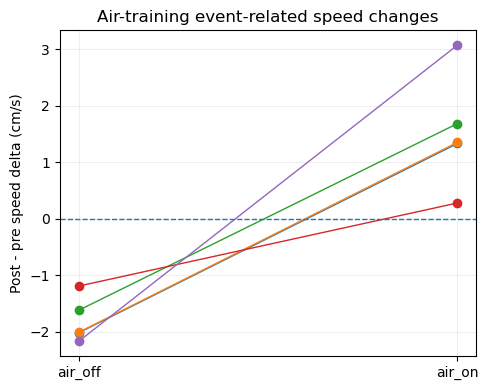

In [17]:
import matplotlib.pyplot as plt

wide = air_on_vs_off["wide_table"]

plt.figure(figsize=(5, 4))

for animal in wide.index:
    plt.plot(
        ["air_off", "air_on"],
        [wide.loc[animal, "air_off"], wide.loc[animal, "air_on"]],
        marker="o",
        linewidth=1
    )

plt.axhline(0, linestyle="--", linewidth=1)
plt.ylabel("Post - pre speed delta (cm/s)")
plt.title("Air-training event-related speed changes")
plt.grid(alpha=0.2)
plt.tight_layout()
plt.show()

In [18]:
from src.proc.behavior_metrics import paired_anchor_comparison

tone_air_on_vs_tone_on = paired_anchor_comparison(
    tone_forward_animal,
    anchor_a="air_on",
    anchor_b="tone_on"
)

tone_on_vs_tone_off = paired_anchor_comparison(
    tone_forward_animal,
    anchor_a="tone_on",
    anchor_b="tone_off"
)

tone_on_vs_air_off = paired_anchor_comparison(
    tone_forward_animal,
    anchor_a="tone_on",
    anchor_b="air_off"
)

tone_air_on_vs_tone_on, tone_on_vs_tone_off, tone_on_vs_air_off

({'anchor_a': 'air_on',
  'anchor_b': 'tone_on',
  'n_animals': 5,
  'mean_delta_a': 0.5260204774667615,
  'mean_delta_b': 0.11887587116656154,
  'mean_difference_a_minus_b': 0.4071446063002,
  'p_paired_ttest': 0.002336956860346046,
  'p_wilcoxon': 0.0625,
  'wide_table': anchor_name   air_off    air_on  tone_off   tone_on
  animal                                             
  NML_04      -0.032597  0.513990 -0.050702  0.073315
  NML_05      -0.157034  0.388945 -0.040251  0.193000
  NML_06      -0.264779  0.620998  0.003920  0.179894
  NML_07      -0.187014  0.466356  0.053052  0.067367
  NML_08      -0.113007  0.639814  0.068546  0.080803},
 {'anchor_a': 'tone_on',
  'anchor_b': 'tone_off',
  'n_animals': 5,
  'mean_delta_a': 0.11887587116656154,
  'mean_delta_b': 0.006913058638730556,
  'mean_difference_a_minus_b': 0.11196281252783095,
  'p_paired_ttest': 0.06302442847579465,
  'p_wilcoxon': 0.0625,
  'wide_table': anchor_name   air_off    air_on  tone_off   tone_on
  animal       

In [20]:

from src.proc.behavior_metrics import run_2way_rm_anova


aov_air_speed, air_speed_rm_table = run_2way_rm_anova(
    session_epoch_df,
    phase="air_training",
    outcome="mean_speed_path_cms"
)

print(aov_air_speed)
air_speed_rm_table

                          Anova
                            F Value  Num DF Den DF Pr > F
---------------------------------------------------------
anchor_name                 126.1013 1.0000 4.0000 0.0004
window_position               0.5797 1.0000 4.0000 0.4889
anchor_name:window_position  31.4722 1.0000 4.0000 0.0050



,animal,anchor_name,window_position,value,n_sessions
0,NML_04,air_off,post,4.358686,15
1,NML_04,air_off,pre,6.373321,15
2,NML_04,air_on,post,2.488235,15
3,NML_04,air_on,pre,1.155508,15
4,NML_05,air_off,post,3.214404,15
5,NML_05,air_off,pre,5.219622,15
6,NML_05,air_on,post,2.852940,15
7,NML_05,air_on,pre,1.500493,15
8,NML_06,air_off,post,3.964607,15
9,NML_06,air_off,pre,5.580624,15


In [21]:
aov_tone_forward, tone_forward_rm_table = run_2way_rm_anova(
    session_epoch_df,
    phase="tone_air_training",
    outcome="frac_forward"
)

print(aov_tone_forward)
tone_forward_rm_table

                          Anova
                            F Value Num DF  Den DF Pr > F
---------------------------------------------------------
anchor_name                 86.9256 3.0000 12.0000 0.0000
window_position             89.6214 1.0000  4.0000 0.0007
anchor_name:window_position 57.6261 3.0000 12.0000 0.0000



,animal,anchor_name,window_position,value,n_sessions
0,NML_04,air_off,post,0.781295,10
1,NML_04,air_off,pre,0.813892,10
2,NML_04,air_on,post,0.657434,10
3,NML_04,air_on,pre,0.143444,10
4,NML_04,tone_off,post,0.890260,10
5,NML_04,tone_off,pre,0.940963,10
6,NML_04,tone_on,post,0.229693,10
7,NML_04,tone_on,pre,0.156377,10
8,NML_05,air_off,post,0.802082,10
9,NML_05,air_off,pre,0.959116,10


In [22]:

from src.proc.behavior_metrics import run_delta_rm_anova


aov_air_delta_speed, air_delta_speed_rm_table = run_delta_rm_anova(
    delta_speed_df,
    phase="air_training",
    outcome="mean_speed_path_cms"
)

print(aov_air_delta_speed)
air_delta_speed_rm_table

                 Anova
            F Value Num DF Den DF Pr > F
----------------------------------------
anchor_name 31.4722 1.0000 4.0000 0.0050



,animal,anchor_name,value,n_sessions
0,NML_04,air_off,-2.014635,15
1,NML_04,air_on,1.332727,15
2,NML_05,air_off,-2.005219,15
3,NML_05,air_on,1.352447,15
4,NML_06,air_off,-1.616017,15
5,NML_06,air_on,1.684464,15
6,NML_07,air_off,-1.188470,16
7,NML_07,air_on,0.280734,16
8,NML_08,air_off,-2.165299,17
9,NML_08,air_on,3.071270,17


In [23]:
aov_tone_delta_forward, tone_delta_forward_rm_table = run_delta_rm_anova(
    delta_forward_df,
    phase="tone_air_training",
    outcome="frac_forward"
)

print(aov_tone_delta_forward)
tone_delta_forward_rm_table

                  Anova
            F Value Num DF  Den DF Pr > F
-----------------------------------------
anchor_name 57.6261 3.0000 12.0000 0.0000



,animal,anchor_name,value,n_sessions
0,NML_04,air_off,-0.032597,10
1,NML_04,air_on,0.513990,10
2,NML_04,tone_off,-0.050702,10
3,NML_04,tone_on,0.073315,10
4,NML_05,air_off,-0.157034,10
5,NML_05,air_on,0.388945,10
6,NML_05,tone_off,-0.040251,10
7,NML_05,tone_on,0.193000,10
8,NML_06,air_off,-0.264779,10
9,NML_06,air_on,0.620998,10


In [27]:
from src.proc.behavior_metrics import add_day_bin
session_epoch_df = add_day_bin(session_epoch_df, n_bins=3)
delta_speed_df = add_day_bin(delta_speed_df, n_bins=3)
delta_forward_df = add_day_bin(delta_forward_df, n_bins=3)

In [28]:

from src.proc.behavior_metrics import run_3way_rm_anova_with_day

aov_air_speed_day, air_speed_day_table = run_3way_rm_anova_with_day(
    session_epoch_df,
    phase="air_training",
    outcome="mean_speed_path_cms"
)

print(aov_air_speed_day)

                              Anova
                                    F Value  Num DF Den DF Pr > F
-----------------------------------------------------------------
anchor_name                         127.9216 1.0000 4.0000 0.0003
window_position                       0.4620 1.0000 4.0000 0.5340
day_bin                               3.3148 2.0000 8.0000 0.0894
anchor_name:window_position          33.6294 1.0000 4.0000 0.0044
anchor_name:day_bin                   4.3502 2.0000 8.0000 0.0527
window_position:day_bin               1.5295 2.0000 8.0000 0.2738
anchor_name:window_position:day_bin   0.5393 2.0000 8.0000 0.6030



In [35]:
from src.proc.behavior_metrics import run_anchor_specific_rm_anova

aov_air_on_speed, air_on_speed_table = run_anchor_specific_rm_anova(
    session_epoch_df,
    phase="air_training",
    anchor_name="air_off",
    outcome="mean_speed_path_cms"
)

print(aov_air_on_speed)

                        Anova
                        F Value  Num DF Den DF Pr > F
-----------------------------------------------------
window_position         105.9455 1.0000 4.0000 0.0005
day_bin                   4.5846 2.0000 8.0000 0.0471
window_position:day_bin   0.2654 2.0000 8.0000 0.7734



In [34]:
from src.proc.behavior_metrics import run_anchor_delta_day_rm_anova
aov_air_on_delta_day, air_on_delta_day_table = run_anchor_delta_day_rm_anova(
    delta_speed_df,
    phase="air_training",
    anchor_name="air_off",
    outcome="mean_speed_path_cms"
)

print(aov_air_on_delta_day)

               Anova
        F Value Num DF Den DF Pr > F
------------------------------------
day_bin  0.2654 2.0000 8.0000 0.7734

